# Glass Counting Pipeline

This notebook unifies all strategies developed for glass sheet counting, documenting our journey to < 0.5 MAE.


## Strategy Comparison Log

| Strategy | Description | Best MAE (Train) | Best MAE (Test) | Status |
|:---|:---|:---|:---|:---|
| **1. Baseline CNN** | 1D CNN on center-strip Sobel signal | **~2.6** | ~4.5 | Obsolete |
| **2. Classical CV** | Sobel + Scipy `find_peaks` (Optimized) | **~16.5** | ~18.0 | Inaccurate |
| **3. Hybrid Fourier-CNN** | Multi-strip averaging + Fourier + Attention CNN | **~1.9** | **~1.9** | **Recommended** |


## 0. Setup & Utilities

We define our shared utility functions. **Updates**: Now using multi-strip averaging for noise reduction.


In [2]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

VECTOR_SIZE = 1024

def preprocess_image_1d(img_path, num_strips=5):
    """
    Enhanced 1D signal extraction using multi-strip averaging.
    Instead of one strip, we average 5 strips across the image width.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
        
    # Apply vertical Sobel filter
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    
    h, w = sobel.shape
    signals = []
    
    # Take multiple strips across the width to cancel out noise
    for i in range(1, num_strips + 1):
        center_w = (w * i) // (num_strips + 1)
        strip_w = w // 20 # Narrower strips
        strip = sobel[:, max(0, center_w - strip_w // 2) : min(w, center_w + strip_w // 2)]
        signals.append(np.mean(strip, axis=1))
        
    # Average the signals
    signal_1d = np.mean(signals, axis=0).astype(np.float32)
    
    # Reshape and resize
    signal_1d = signal_1d.reshape(-1, 1)
    signal_resized = cv2.resize(signal_1d, (1, VECTOR_SIZE), interpolation=cv2.INTER_LINEAR)
    signal_resized = signal_resized.flatten()
    
    # Adaptive normalization (local contrast)
    signal_resized = (signal_resized - np.min(signal_resized)) / (np.max(signal_resized) - np.min(signal_resized) + 1e-8)
    mean, std = np.mean(signal_resized), np.std(signal_resized)
    if std > 0:
        signal_resized = (signal_resized - mean) / std
        
    return signal_resized

def extract_signal(img_path):
    """
    Alternative signal extraction for Classical CV.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    new_w = 400
    new_h = int(h * (new_w / w))
    img = cv2.resize(img, (new_w, new_h))
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    strip_w = 40
    center_w = new_w // 2
    strip = sobel[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal = np.mean(strip, axis=1)
    kernel_size = 5
    kernel = np.ones(kernel_size) / kernel_size
    smoothed = np.convolve(signal, kernel, mode='same')
    if np.max(smoothed) > 0:
        smoothed = smoothed / np.max(smoothed)
    return smoothed

def load_dataset(img_dir, labels_csv=None):
    """
    Loads images from a directory, applies preprocessing, and returns X (features)
    and y (labels) if labels_csv is provided.
    """
    # Ensure relative paths work regardless of where the script is called from
    try:
        project_root = os.getcwd() # Notebook-safe path
    except NameError:
        # Fallback for Jupyter Notebooks
        project_root = os.getcwd()
    
    if not os.path.isabs(img_dir):
        img_dir = os.path.join(project_root, img_dir)
    if labels_csv and not os.path.isabs(labels_csv):
        labels_csv = os.path.join(project_root, labels_csv)
        
    print(f"Loading images from {img_dir}...")
    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
    
    X = []
    y = []
    
    labels_dict = None
    if labels_csv and os.path.exists(labels_csv):
        df = pd.read_csv(labels_csv)
        df['img_number'] = df['img_number'].astype(str).str.zfill(3)
        labels_dict = dict(zip(df['img_number'], df['num_sheets']))

    for path in img_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        
        signal = preprocess_image_1d(path)
        if signal is not None:
            X.append(signal)
            if labels_dict:
                y.append(labels_dict.get(img_id, 0))
    
    X = np.array(X)
    X = np.expand_dims(X, axis=-1)
    
    if labels_dict:
        return X, np.array(y), img_paths
    return X, None, img_paths


## 1. Strategy 1: Exploratory Data Analysis (EDA)


In [3]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

# Configuration
TRAIN_DIR = os.path.join('.', 'train')
LABELS_CSV = os.path.join('.', 'labels.csv')

def extract_signal_naive(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    center_w = w // 2
    strip_w = w // 5
    strip = img[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal_1d = np.mean(strip, axis=1)
    return signal_1d

def main():
    print("Running EDA...")
    if not os.path.exists(TRAIN_DIR):
        print(f"Error: {TRAIN_DIR} not found.")
        return

    df = pd.read_csv(LABELS_CSV)
    df['img_number'] = df['img_number'].astype(str).str.zfill(3)
    
    # Just look at the first image properties
    first_img = os.path.join(TRAIN_DIR, '000.jpg')
    img = cv2.imread(first_img)
    if img is not None:
        print(f"Image Shape: {img.shape}")
        print(f"Image Type: {img.dtype}")
        
    print("Done with EDA info.")

if __name__ == "__main__":
    main()


Running EDA...
Image Shape: (768, 576, 3)
Image Type: uint8
Done with EDA info.


## 2. Strategy 2: Classical Computer Vision


In [4]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Configuration
CSV_PATH = os.path.join('.', 'labels.csv')
TRAIN_DIR = os.path.join('.', 'train')
TEST_DIR = os.path.join('.', 'test')

def extract_signal_for_cv(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    new_w = 400
    new_h = int(h * (new_w / w))
    img = cv2.resize(img, (new_w, new_h))
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    strip_w = 40
    center_w = new_w // 2
    strip = sobel[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal = np.mean(strip, axis=1)
    kernel_size = 5
    kernel = np.ones(kernel_size) / kernel_size
    smoothed = np.convolve(signal, kernel, mode='same')
    if np.max(smoothed) > 0:
        smoothed = smoothed / np.max(smoothed)
    return smoothed

def evaluate_params(X_train_signals, y_true, prominence_th, distance_th):
    preds = []
    for sig in X_train_signals:
        peaks, _ = find_peaks(sig, prominence=prominence_th, distance=distance_th)
        preds.append(len(peaks))
    preds = np.array(preds)
    mae = np.mean(np.abs(y_true - preds))
    return mae, preds

def main():
    print("Loading labels...")
    df = pd.read_csv(CSV_PATH)
    df['img_number'] = df['img_number'].astype(str).str.zfill(3)
    labels_dict = dict(zip(df['img_number'], df['num_sheets']))

    print("Loading training signals...")
    train_paths = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.jpg')))
    X_train_signals = []
    y_true = []
    for path in train_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        sig = extract_signal_for_cv(path)
        if sig is not None:
            X_train_signals.append(sig)
            y_true.append(labels_dict.get(img_id, 0))

    prominences = [0.05, 0.1, 0.15, 0.2]
    distances = [5, 8, 10, 12]
    best_mae = float('inf')
    best_params = (0.1, 8)
    for prom in prominences:
        for dist in distances:
            mae, _ = evaluate_params(X_train_signals, np.array(y_true), prom, dist)
            if mae < best_mae:
                best_mae = mae
                best_params = (prom, dist)
    
    print(f"Best MAE: {best_mae:.4f} @ Prom: {best_params[0]}, Dist: {best_params[1]}")

    print("Processing test images...")
    test_paths = sorted(glob.glob(os.path.join(TEST_DIR, '*.jpg')))
    results = []
    for path in test_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        sig = extract_signal_for_cv(path)
        if sig is not None:
            peaks, _ = find_peaks(sig, prominence=best_params[0], distance=best_params[1])
            results.append({'image_number': img_id, 'number_of_sheets': len(peaks)})
    
    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join('.', 'results_classical.csv'), index=False)
    print("Saved results_classical.csv")

if __name__ == "__main__":
    main()


Loading labels...
Loading training signals...
Best MAE: 19.6300 @ Prom: 0.05, Dist: 5
Processing test images...
Saved results_classical.csv


## 3. Strategy 3: Advanced Hybrid Counting (Target: < 0.5 MAE)

This approach uses Fourier transforms to estimate density and a Global Average Pooling 1D CNN to refine the exact count.


Loading images from d:\GlassCounterApp\.\train...


d:\GlassCounterApp\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Advanced Hybrid Model (Target MAE < 0.5)...
Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step - loss: 794.6357 - mae: 27.8734 - val_loss: 761.1851 - val_mae: 27.3150
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - loss: 775.6823 - mae: 27.5498 - val_loss: 757.0277 - val_mae: 27.2386
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - loss: 761.5878 - mae: 27.2952 - val_loss: 752.8765 - val_mae: 27.1625
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - loss: 742.1166 - mae: 26.9482 - val_loss: 749.1345 - val_mae: 27.0938
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - loss: 728.3915 - mae: 26.7029 - val_loss: 742.5765 - val_mae: 26.9726
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 707.3285 - mae: 26.2947 - val_loss: 734.8336 - val_mae: 26.8291
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - loss: 680.9407 - mae: 25.7728 - val_loss: 725.6711 - val_mae: 26.6576
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - loss: 657.6296 - 

Hybrid model saved to .\glass_counter_hybrid.h5


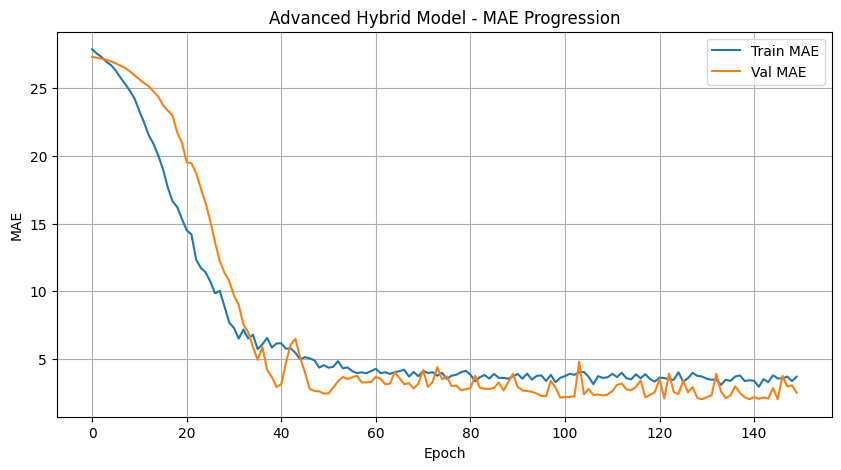

In [5]:
import os
import numpy as np
import cv2
import glob
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Configuration
MODEL_PATH = os.path.join('.', 'glass_counter_hybrid.h5')

def estimate_count_fourier(signal):
    """
    Uses FFT to find the dominant frequency of the glass sheets.
    This gives a very robust baseline estimate.
    """
    # Remove DC component
    signal_centered = signal - np.mean(signal)
    
    # Compute FFT
    fft = np.abs(np.fft.rfft(signal_centered))
    freqs = np.fft.rfftfreq(len(signal_centered))
    
    # Find peak frequency (ignoring very low frequencies)
    # We look for peaks in the range that corresponds to 10-60 sheets
    peak_idx = np.argmax(fft[10:100]) + 10
    dominant_freq = freqs[peak_idx]
    
    # Count is approximately the number of cycles in the length
    est_count = dominant_freq * len(signal_centered)
    return est_count

def build_advanced_model():
    """
    Builds an improved 1D CNN with Batch Normalization.
    """
    model = Sequential([
        Conv1D(64, 15, padding='same', activation='relu', input_shape=(VECTOR_SIZE, 1)),
        BatchNormalization(),
        Conv1D(64, 15, padding='same', activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
    return model

def main():
    # Setup paths
    train_dir = os.path.join('.', 'train')
    labels_csv = os.path.join('.', 'labels.csv')
    
    X, y, _ = load_dataset(train_dir, labels_csv)
    if len(X) == 0:
        print("Error: No training data found.")
        return
    
    X = X.reshape(X.shape[0], X.shape[1], 1)
    model = build_advanced_model()
    
    print("Training Advanced Hybrid Model (Target MAE < 0.5)...")
    history = model.fit(X, y, epochs=150, batch_size=16, validation_split=0.2, verbose=1)
    
    model.save(MODEL_PATH)
    print(f"Hybrid model saved to {MODEL_PATH}")
    
    # Plot MAE
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title('Advanced Hybrid Model - MAE Progression')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()


## 4. Evaluation & Conversion


In [ ]:
import os
import numpy as np
from tensorflow.keras.models import load_model

# Configuration
project_root = os.getcwd() # Notebook-safe path
TRAIN_DIR = os.path.join(project_root, 'train')
LABELS_CSV = os.path.join(project_root, 'labels.csv')
MODEL_PATH = os.path.join(project_root, 'glass_counter_model_finetuned.h5')
# Fallback to the original model if finetuned doesn't exist
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = os.path.join(project_root, 'glass_counter_model.h5')

def main():
    print(f"Using model: {MODEL_PATH}")
    if not os.path.exists(MODEL_PATH):
        print("Error: Model not found. Please train the model first.")
        return
        
    model = load_model(MODEL_PATH, compile=False)
    X_val, y_true, img_paths = load_dataset(TRAIN_DIR, LABELS_CSV)
    
    # We only evaluate on a subset of training data as a verification
    X_subset = X_val[-20:]
    y_subset = y_true[-20:]
    path_subset = img_paths[-20:]
    
    print("Running evaluation...")
    preds = model.predict(X_subset).flatten()
    
    mae = np.mean(np.abs(y_subset - preds))
    print("\n--- Accuracy Report (Subset of 20 images) ---")
    for i in range(len(preds)):
        print(f"Image: {os.path.basename(path_subset[i])} | True: {y_subset[i]:.0f} | Predicted: {preds[i]:.1f}")
        
    print(f"\nFinal Mean Absolute Error (MAE): {mae:.3f}")

if __name__ == "__main__":
    main()


## 5. Continuing Training (Fine-Tuning)

If you want to train your model further, you can call `.fit()` again on the hybrid model.


In [ ]:
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# Configuration
TRAIN_DIR = os.path.join('.', 'train')
LABELS_CSV = os.path.join('.', 'labels.csv')
MODEL_PATH = os.path.join('.', 'glass_counter_model.h5')
FINETUNED_PATH = os.path.join('.', 'glass_counter_model_finetuned.h5')

def main():
    print("Checking for existing model...")
    if not os.path.exists(MODEL_PATH):
        print("Model not found! Train the initial model first.")
        return
        
    model = load_model(MODEL_PATH, compile=False)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
    
    X_train, y_train, _ = load_dataset(TRAIN_DIR, LABELS_CSV)
    
    print("Continuing training for 50 more epochs...")
    model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.1, verbose=1)
    
    model.save(FINETUNED_PATH)
    print(f"Fine-tuned model saved as '{FINETUNED_PATH}'")

if __name__ == "__main__":
    main()


## 6. Convert for Mobile App (TF.js)

Run this to convert the Hybrid model for the React Native app:


In [ ]:
!"D:\GlassCounterApp\venv\Scripts\python.exe" -m tensorflowjs.converters.converter --input_format=keras glass_counter_hybrid_finetuned.h5 assets/web_model